# ```Are Prices Justified? - IPL 2026```

In [10]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
batters = pd.read_csv(r"C:\Users\Rano's PC\Machine\InsightForge\InsightForge\Are Prices Justified - IPL 2026\_dataset\_cleaned_data\batters.csv")
bowlers = pd.read_csv(r"C:\Users\Rano's PC\Machine\InsightForge\InsightForge\Are Prices Justified - IPL 2026\_dataset\_cleaned_data\bowlers.csv")

In [3]:
batters.head()

,pos,player,runs,mat,inns,no,sr,boundary_pct,avg_balls_inns,base_price,final_price,role,final_price_rate
0,71,Abdul Samad,116,8,8,2,131.81,60.34,11.00,3000000,42000000,Uncapped,14.0
1,8,Abhishek Sharma,563,15,15,1,204.72,81.35,18.33,2000000,65000000,Capped,32.5
2,156,Adam Milne,2,1,1,1,100.00,0.00,2.00,20000000,24000000,Capped,1.2
3,46,Aiden Markram,231,12,11,2,138.32,63.20,15.18,20000000,20000000,Capped,1.0
4,27,Ajinkya Rahane,335,14,14,1,135.08,62.09,17.71,15000000,15000000,Capped,1.0


In [4]:
bowlers.head()

,pos,player,wkts,mat,inns,ov,runs,avg,econ,sr,base_price,final_price,role,final_price_rate
0,75,Abhinandan Singh,3,3,3,9.4,122,40.66,12.62,19.33,3000000,3000000,Uncapped,1.00
1,72,Akash Singh,4,2,2,7.0,80,20.00,11.42,10.50,3000000,3000000,Uncapped,1.00
2,44,Akeal Hosein,8,7,7,24.4,198,24.75,8.02,18.50,20000000,20000000,Capped,1.00
3,5,Anshul Kamboj,21,14,14,50.2,530,25.23,10.52,14.38,3000000,34000000,Uncapped,11.33
4,39,Anukul Roy,9,14,12,27.1,261,29.00,9.60,18.11,3000000,4000000,Uncapped,1.33


In [6]:
batters = batters[batters['inns']>5]

In [7]:
bowlers = bowlers[bowlers['inns']>5]

In [8]:
batters.head()

,pos,player,runs,mat,inns,no,sr,boundary_pct,avg_balls_inns,base_price,final_price,role,final_price_rate
0,71,Abdul Samad,116,8,8,2,131.81,60.34,11.00,3000000,42000000,Uncapped,14.0
1,8,Abhishek Sharma,563,15,15,1,204.72,81.35,18.33,2000000,65000000,Capped,32.5
3,46,Aiden Markram,231,12,11,2,138.32,63.20,15.18,20000000,20000000,Capped,1.0
4,27,Ajinkya Rahane,335,14,14,1,135.08,62.09,17.71,15000000,15000000,Capped,1.0
7,20,Angkrish Raghuvanshi,422,13,12,2,146.52,64.93,24.00,3000000,30000000,Uncapped,10.0


In [9]:
bowlers.head()

,pos,player,wkts,mat,inns,ov,runs,avg,econ,sr,base_price,final_price,role,final_price_rate
2,44,Akeal Hosein,8,7,7,24.4,198,24.75,8.02,18.50,20000000,20000000,Capped,1.00
3,5,Anshul Kamboj,21,14,14,50.2,530,25.23,10.52,14.38,3000000,34000000,Uncapped,11.33
4,39,Anukul Roy,9,14,12,27.1,261,29.00,9.60,18.11,3000000,4000000,Uncapped,1.33
6,21,Arshdeep Singh,14,14,14,53.0,541,38.64,10.20,22.71,20000000,180000000,Capped,9.00
7,55,Ashok Sharma,6,6,6,21.0,228,38.00,10.85,21.00,3000000,9000000,Uncapped,3.00


## 4.Data Analysis

In [37]:
def plot_kde(data, columns):
    colours = ['teal','blue','green','cyan']
    fig, axes = plt.subplots(2, 4, figsize=(24,10))
    axes = axes.flatten()
    
    for i, column in enumerate(columns):
        ax = axes[i]
        sns.kdeplot(x=column, data=data, fill=True, linewidth=3, color=random.choice(colours), ax=ax)
        ax.axvline(data[column].mean(), color='red', linestyle='--', label='Mean')
        ax.axvline(data[column].quantile(.95), color='black', linestyle='--', label='95th %ile')
        ax.axvline(data[column].median(), color='yellow', linestyle='--', label='Median')
        ax.set_title(f"{column.title()} Distribution")
        ax.legend()
    
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

### 4.1 Univariate Analysis

**BATTERS**

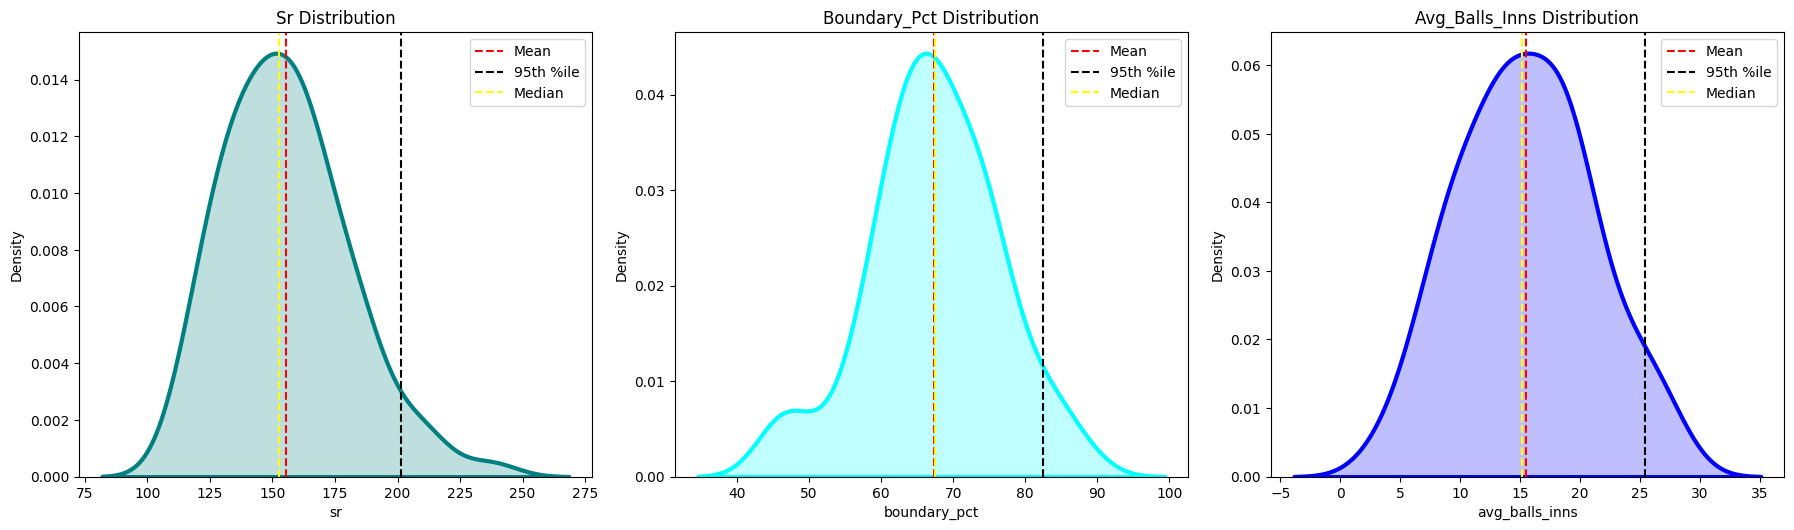

In [43]:
columns = ['sr', 'boundary_pct','avg_balls_inns']

plot_kde(batters,columns=columns)

**BOWLERS**

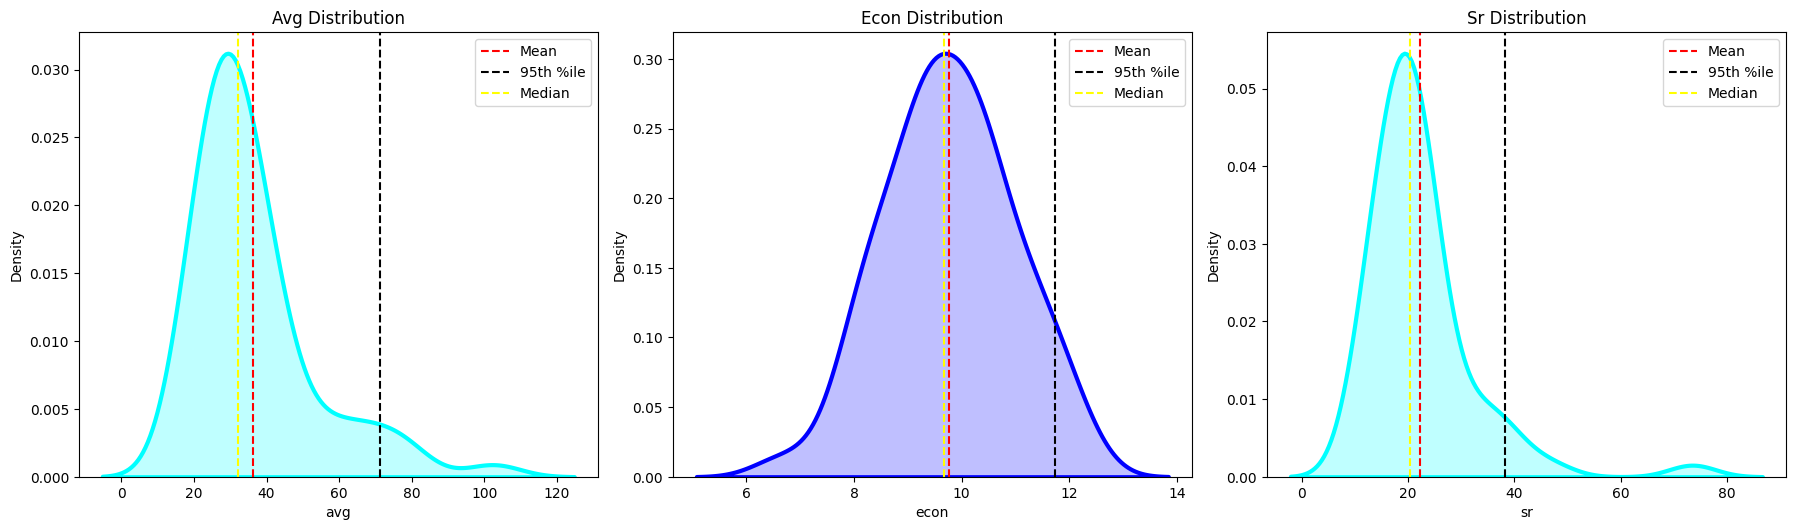

In [39]:
columns = ['avg','econ','sr']

plot_kde(bowlers,columns=columns)

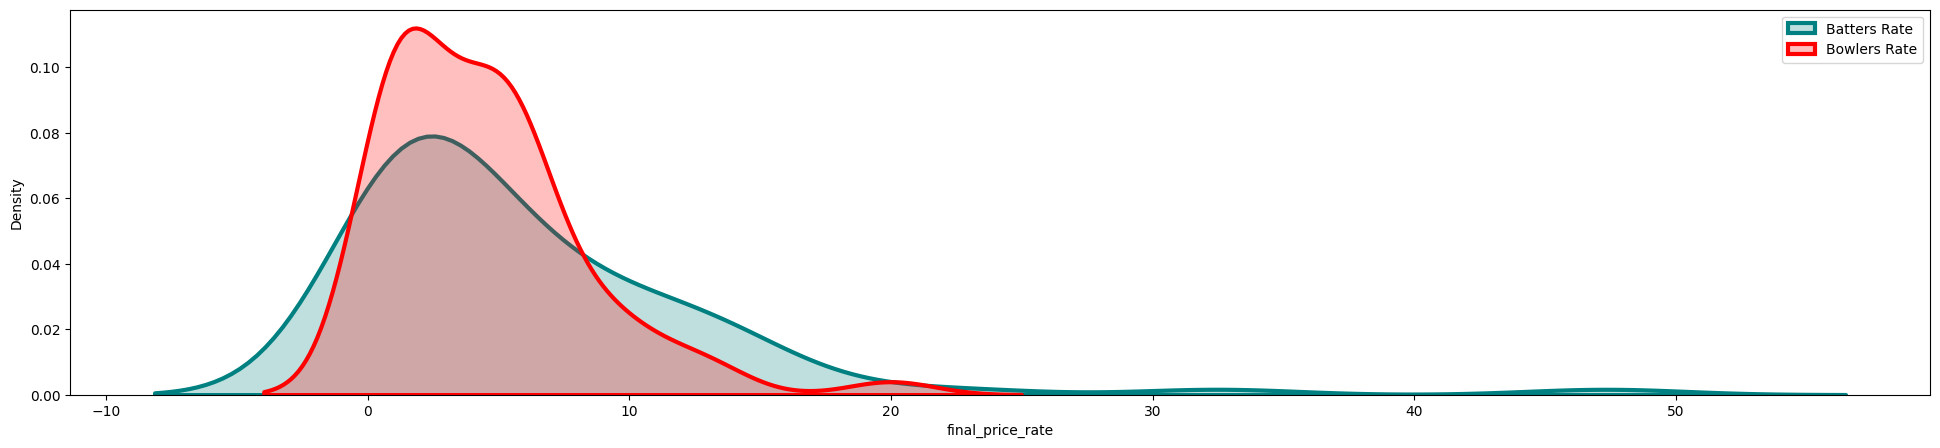

In [36]:
plt.figure(figsize=(24,5))
sns.kdeplot(x = 'final_price_rate',data = batters,linewidth = 3,fill=True,color = 'teal',label = 'Batters Rate')
sns.kdeplot(x = 'final_price_rate',data = bowlers,linewidth = 3,fill=True,color = 'red',label = 'Bowlers Rate')
plt.legend()
plt.show()

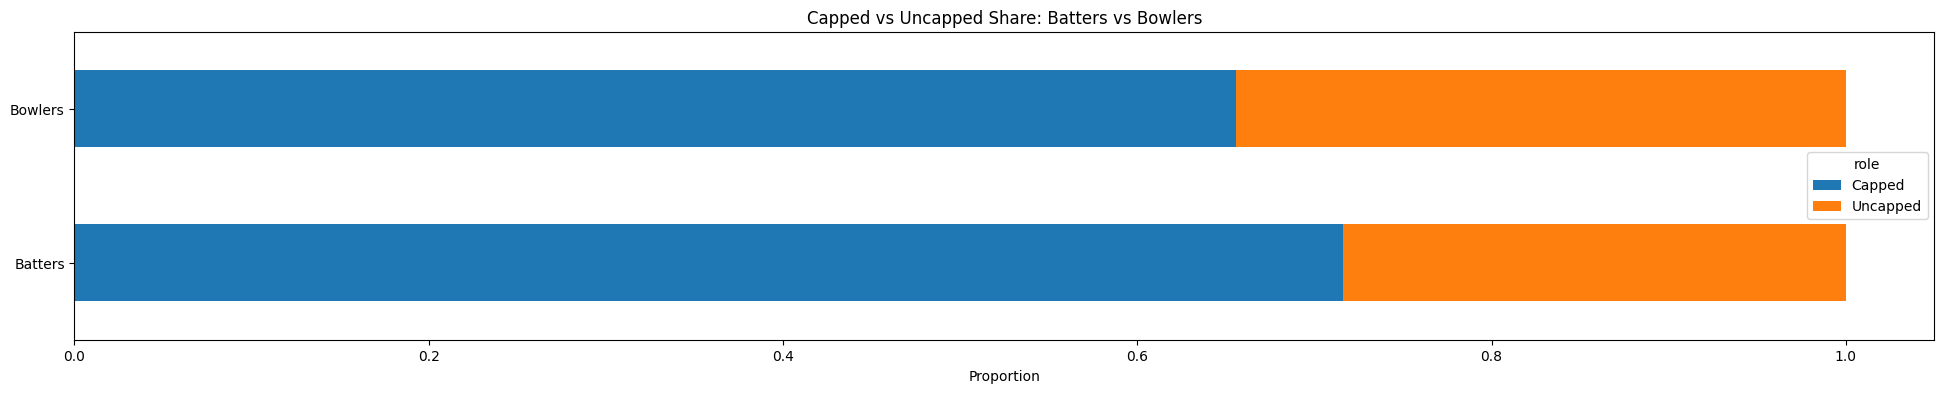

In [58]:
comparison = pd.DataFrame({
    'Batters': batters['role'].value_counts(normalize=True),
    'Bowlers': bowlers['role'].value_counts(normalize=True)
}).T

comparison.plot(kind='barh', stacked=True, figsize=(24,4))
plt.title('Capped vs Uncapped Share: Batters vs Bowlers')
plt.xlabel('Proportion')
plt.show()

### 4.2 Bivariate Analysis

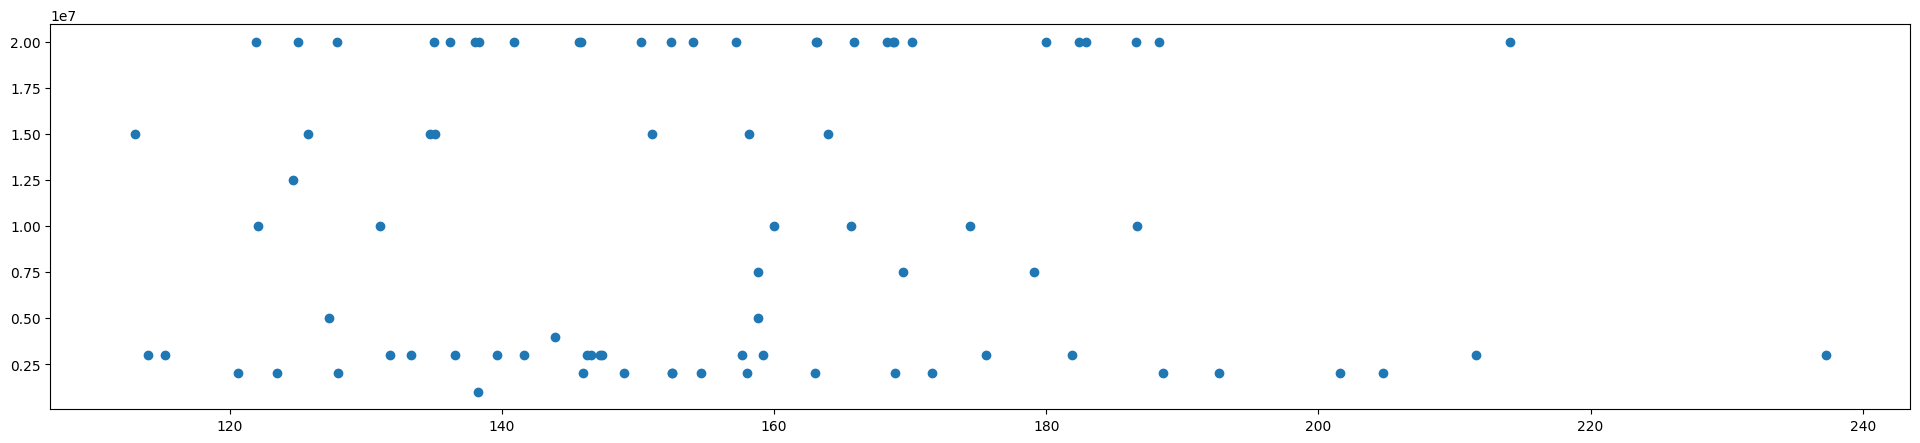

In [59]:
plt.figure(figsize=(24,5))
plt.scatter(x= 'sr',y='base_price',data=batters)
plt.show()

## 5.Justification

### 5.1 Batters

5.1.1 Capped

5.1.2 Uncapped

### 6.1 Bowlers

6.1.1 Capped

6.1.2 Uncapped